In [1]:
# 필요한 라이브러리를 임포트합니다
import platform
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

# ========================================
# 운영체제별 한글 폰트 설정
# ========================================
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

print("라이브러리 로드 완료")

/Users/jin/Develop/codingclub/game-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


라이브러리 로드 완료


In [2]:
df_reviews = pd.read_csv('../../../../data/preprocessed/steam_indie_reviews.csv')
print(f'전체 리뷰: {len(df_reviews):,}건 로드 완료')

전체 리뷰: 166,875건 로드 완료


In [3]:
# 분석 대상 게임 설정
TARGET_APPID = 1054510
# 리뷰 최소 텍스트 수
min_length = 10

df_game = (
    df_reviews[
        (df_reviews['appid'] == TARGET_APPID) &
        (df_reviews['language'] == 'english')
    ]
    .dropna(subset=['review'])
    .pipe(lambda d: d[d['review'].str.strip() != ''])
    .pipe(lambda d: d[d['review'].str.len() >= min_length])
    .reset_index(drop=True)
)

In [4]:
# df_game 기반으로 분석용 변수를 추출합니다
filtered_docs = df_game['review'].tolist()
filtered_labels = df_game['voted_up'].astype(int).values  # True/False → 1/0
label_names = {1: '긍정', 0: '부정'}

# 긍정/부정 분리
df_neg = df_game[~df_game['voted_up']].reset_index(drop=True)
df_pos = df_game[df_game['voted_up']].reset_index(drop=True)
neg_docs = df_neg['review'].tolist()
pos_docs = df_pos['review'].tolist()

print(f"분석 대상: {len(filtered_docs):,}건 (최소 {min_length}자 이상, 영어)")
print(f"  긍정: {len(pos_docs):,}건 / 부정: {len(neg_docs):,}건")

분석 대상: 1,500건 (최소 10자 이상, 영어)
  긍정: 1,319건 / 부정: 181건


In [5]:
# 필터링 결과를 확인합니다
print("필터링된 데이터 미리보기 (5건):")
display(df_game[['voted_up', 'review']].head())

print()
print("텍스트 길이 통계:")
display(df_game['review'].str.len().describe().to_frame("review_length").T)

필터링된 데이터 미리보기 (5건):


,voted_up,review
0,True,First off I'd like to say that the developer b...
1,True,Great Game
2,True,Amazing gem of a game that I've played since t...
3,True,day 1 purchase for me having clocked over 200 ...
4,True,The original survivalist is among my favorite ...



텍스트 길이 통계:


,count,mean,std,min,25%,50%,75%,max
review_length,1500.0,505.472,852.5135,10.0,72.0,216.0,556.25,7948.0


In [6]:
# 임베딩 모델을 로드합니다
EMBEDDING_MODEL_NAME = "avsolatorio/GIST-small-Embedding-v0"
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME) # 허깅페이스 라이브러리


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4078.71it/s]


In [7]:

import hashlib
import json
import os


def docs_fingerprint(docs: list[str]) -> str:
    """문서 목록이 바뀌었는지 확인하기 위한 짧은 해시입니다."""
    h = hashlib.sha256()
    for doc in docs:
        h.update(str(doc).encode('utf-8'))
        h.update(b'\0')
    return h.hexdigest()


def load_or_encode(docs: list[str], path: str, label: str) -> np.ndarray:
    meta_path = f'{path}.meta.json'
    expected_meta = {
        'appid': TARGET_APPID,
        'label': label,
        'model_name': EMBEDDING_MODEL_NAME,
        'doc_count': len(docs),
        'docs_hash': docs_fingerprint(docs),
    }

    def is_valid_cache(embeddings: np.ndarray) -> bool:
        if embeddings.shape[0] != len(docs):
            print(f"캐시 무효: {path} 문서 수 불일치 {embeddings.shape[0]} != {len(docs)}")
            return False
        if not os.path.exists(meta_path):
            print(f"캐시 메타데이터 없음: {meta_path} → 임베딩 재생성")
            return False
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)
        mismatched = [k for k, v in expected_meta.items() if meta.get(k) != v]
        if mismatched:
            print(f"캐시 무효: {path} 메타데이터 불일치 {mismatched}")
            return False
        return True

    if os.path.exists(path):
        embeddings = np.load(path)
        if is_valid_cache(embeddings):
            print(f"로드 완료: {path} {embeddings.shape}")
            return embeddings

    print(f"{label} 리뷰 {len(docs):,}건 임베딩 생성 중...")
    embeddings = embedding_model.encode(docs, show_progress_bar=True)
    np.save(path, embeddings)
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(expected_meta | {'embedding_shape': list(embeddings.shape)}, f, ensure_ascii=False, indent=2)
    print(f"저장 완료: {path} {embeddings.shape}")
    return embeddings


neg_embeddings = load_or_encode(neg_docs, f'../../../../data/processed/embeddings_neg_{TARGET_APPID}.npy', '부정')
pos_embeddings = load_or_encode(pos_docs, f'../../../../data/processed/embeddings_pos_{TARGET_APPID}.npy', '긍정')


부정 리뷰 181건 임베딩 생성 중...


Batches: 100%|██████████| 6/6 [00:02<00:00,  2.10it/s]


저장 완료: ../../../../data/processed/embeddings_neg_1054510.npy (181, 384)
긍정 리뷰 1,319건 임베딩 생성 중...


Batches: 100%|██████████| 42/42 [00:10<00:00,  4.13it/s]

저장 완료: ../../../../data/processed/embeddings_pos_1054510.npy (1319, 384)


In [8]:

def calc_min_cluster_size(n_docs: int) -> int:
    """리뷰 수 구간별로 min_cluster_size를 자동 조정합니다."""
    if n_docs < 30:
        return max(2, int(n_docs * 0.10))
    if n_docs < 100:
        return max(5, int(n_docs * 0.06))
    if n_docs < 500:
        return max(8, int(n_docs * 0.04))
    if n_docs < 2_000:
        return max(15, int(n_docs * 0.03))
    return min(80, max(25, int(n_docs * 0.015)))


def min_cluster_candidates(n_docs: int) -> list[int]:
    base = calc_min_cluster_size(n_docs)
    candidates = [base, int(base * 0.7), int(base * 0.5)]
    lower_bound = 2 if n_docs < 30 else 5
    return sorted({max(lower_bound, c) for c in candidates}, reverse=True)


def build_topic_model(min_cluster_size: int, n_docs: int) -> BERTopic:
    n_neighbors = min(15 if min_cluster_size >= 8 else 5, max(2, n_docs - 1))
    min_df = 1 if n_docs < 30 else 2
    umap_model = UMAP(
        n_components=5,
        n_neighbors=n_neighbors,
        min_dist=0.0,
        metric="cosine",
        random_state=42,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=max(1, min(3, min_cluster_size // 2)),
        metric="euclidean",
    )
    vectorizer_model = CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=min_df,
        max_df=0.95,
    )
    return BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        verbose=False,
    )


def diagnose_topic_quality(topic_info: pd.DataFrame, total_docs: int) -> dict:
    non_noise = topic_info[topic_info['Topic'] != -1]
    noise_count = int(topic_info.loc[topic_info['Topic'] == -1, 'Count'].sum())
    topic_count = len(non_noise)
    largest_ratio = 0.0 if non_noise.empty else float(non_noise['Count'].max() / total_docs)
    noise_ratio = float(noise_count / total_docs) if total_docs else 0.0

    warnings = []
    if topic_count == 0:
        warnings.append('토픽이 생성되지 않았습니다.')
    if largest_ratio >= 0.50 and total_docs >= 100:
        warnings.append('가장 큰 토픽 비중이 50% 이상입니다. 토픽 과대 병합 가능성이 있습니다.')
    if topic_count <= 2 and total_docs >= 200:
        warnings.append('리뷰 수 대비 토픽 수가 적습니다.')
    if noise_ratio >= 0.40:
        warnings.append('노이즈 비중이 40% 이상입니다. 토픽 분리가 불안정할 수 있습니다.')

    return {
        'topic_count': topic_count,
        'noise_count': noise_count,
        'noise_ratio': round(noise_ratio, 3),
        'largest_topic_ratio': round(largest_ratio, 3),
        'warnings': warnings,
    }


def quality_score(diagnostics: dict) -> tuple[int, float, float]:
    return (
        len(diagnostics['warnings']),
        diagnostics['largest_topic_ratio'],
        diagnostics['noise_ratio'],
    )


def fit_topic_model_with_retry(docs: list[str], embeddings: np.ndarray, label: str):
    if len(docs) < 5:
        raise ValueError(f'{label} 리뷰가 너무 적어 BERTopic 분석을 수행할 수 없습니다: {len(docs)}건')

    results = []
    for mcs in min_cluster_candidates(len(docs)):
        print(f"\n{label} 리뷰 BERTopic 학습 중... min_cluster_size={mcs}")
        model = build_topic_model(min_cluster_size=mcs, n_docs=len(docs))
        topics, probs = model.fit_transform(docs, embeddings=embeddings)
        topic_info = model.get_topic_info()
        diagnostics = diagnose_topic_quality(topic_info, len(docs))
        print(
            f"  토픽 수: {diagnostics['topic_count']}개 / "
            f"노이즈: {diagnostics['noise_count']}건 ({diagnostics['noise_ratio'] * 100:.1f}%) / "
            f"최대 토픽 비중: {diagnostics['largest_topic_ratio'] * 100:.1f}%"
        )
        for warning in diagnostics['warnings']:
            print(f"  경고: {warning}")
        results.append((quality_score(diagnostics), mcs, model, topics, probs, diagnostics))
        if not diagnostics['warnings']:
            break

    _, best_mcs, best_model, best_topics, best_probs, best_diagnostics = sorted(results, key=lambda x: x[0])[0]
    print(f"\n{label} 리뷰 최종 min_cluster_size={best_mcs}")
    return best_model, best_topics, best_probs, best_mcs, best_diagnostics


topic_model_neg, neg_topics, neg_probs, neg_mcs, neg_diagnostics = fit_topic_model_with_retry(
    neg_docs, neg_embeddings, '부정'
)
df_neg['topic'] = neg_topics

topic_model_pos, pos_topics, pos_probs, pos_mcs, pos_diagnostics = fit_topic_model_with_retry(
    pos_docs, pos_embeddings, '긍정'
)
df_pos['topic'] = pos_topics



부정 리뷰 BERTopic 학습 중... min_cluster_size=8
  토픽 수: 5개 / 노이즈: 25건 (13.8%) / 최대 토픽 비중: 29.8%

부정 리뷰 최종 min_cluster_size=8

긍정 리뷰 BERTopic 학습 중... min_cluster_size=39
  토픽 수: 2개 / 노이즈: 4건 (0.3%) / 최대 토픽 비중: 94.0%
  경고: 가장 큰 토픽 비중이 50% 이상입니다. 토픽 과대 병합 가능성이 있습니다.
  경고: 리뷰 수 대비 토픽 수가 적습니다.

긍정 리뷰 BERTopic 학습 중... min_cluster_size=27
  토픽 수: 11개 / 노이즈: 184건 (13.9%) / 최대 토픽 비중: 34.6%

긍정 리뷰 최종 min_cluster_size=27


In [9]:
# 토픽 요약 확인
neg_topic_info = topic_model_neg.get_topic_info()
pos_topic_info = topic_model_pos.get_topic_info()

print("=== 부정 리뷰 토픽 요약 ===")
display(neg_topic_info)

print("\n=== 긍정 리뷰 토픽 요약 ===")
display(pos_topic_info)

=== 부정 리뷰 토픽 요약 ===


,Topic,Count,Name,Representation,Representative_Docs
0,-1,25,-1_feels_food_right_thing,"[feels, food, right, thing, mechanics, ll, guy...","[I really wanted to like this game, supporting..."
1,0,54,0_camp_make_base_zombie,"[camp, make, base, zombie, map, ai, work, ammo...",[The problem with Survivalist Invisible strain...
2,1,42,1_menu_ui_want_camera,"[menu, ui, want, camera, refund, settings, gra...",[Badly designed interface:\n * sometimes cont...
3,2,29,2_character_better_view_community,"[character, better, view, community, npc, thin...",[This is a direct sequel to the first game and...
4,3,23,3_needs_hit_skill_zombie,"[needs, hit, skill, zombie, order, right, enem...","[This is a unique zombie apocalypse game, of t..."
5,4,8,4_kenshi_zomboid_feels like_feels,"[kenshi, zomboid, feels like, feels, state, st...",[The game had some depth and you could see it ...



=== 긍정 리뷰 토픽 요약 ===


,Topic,Count,Name,Representation,Representative_Docs
0,-1,184,-1_game_time_community_fun,"[game, time, community, fun, people, play, zom...","[This is my first review ever on steam, and th..."
1,0,457,0_game_zombie_survival_community,"[game, zombie, survival, community, zombies, g...",[It's like My Time At Portia and State of Deca...
2,1,146,1_game_fun_great game_good game,"[game, fun, great game, good game, play, game ...","[great game, fun to play with friends or by yo..."
3,2,124,2_game_updates_bob_dev,"[game, updates, bob, dev, lot, developer, wait...",[This is neither State of Decay nor Project Zo...
4,3,75,3_decay_state decay_state_kenshi,"[decay, state decay, state, kenshi, zomboid, p...",[If you're a Project Zomboid fan tired of wait...
5,4,65,4_game_good game_ui_hope,"[game, good game, ui, hope, needs, fun, add, b...",[no waves of hordes to fend off needlessly unl...
6,5,58,5_sandbox_game_access_early access,"[sandbox, game, access, early access, story, m...",[Finally out of early access and it's been wor...
7,6,57,6_10_zombies_10 10_started,"[10, zombies, 10 10, started, people, camp, go...","[Day 1\n\nMy travels have taken a toll on me, ..."
8,7,49,7_fun_game_hard_bit,"[fun, game, hard, bit, challenging, recommend,...",[Expect a bit of a learning curve (and to die ...
9,8,41,8_buy_nice_mate_good value,"[buy, nice, mate, good value, gem, worth, hidd...",[This is a little gem that is way deeper than ...



**해석:** 각 토픽의 `Count`는 해당 토픽에 배정된 리뷰 수이며, `-1`은 어떤 토픽에도 속하지 않은 노이즈 리뷰입니다. `min_cluster_size`는 리뷰 수 구간에 따라 자동 계산한 뒤, 최대 토픽 비중·노이즈 비중·토픽 수를 점검하여 과대 병합 가능성이 있으면 더 작은 후보값으로 재시도합니다. 대시보드에서 개발자가 여러 게임을 선택하는 상황을 고려해, 단일 고정 비율보다 안정적인 자동 튜닝 흐름을 사용합니다.


In [10]:

# 토픽별 상위 키워드 인터랙티브 차트
neg_topic_ids = [t for t in neg_topic_info["Topic"] if t != -1]
pos_topic_ids = [t for t in pos_topic_info["Topic"] if t != -1]

print("=== 부정 리뷰 토픽별 키워드 ===")
if neg_topic_ids:
    topic_model_neg.visualize_barchart(
        top_n_topics=len(neg_topic_ids),
        n_words=8,
        title=f'부정 리뷰 토픽별 키워드 (appid={TARGET_APPID})',
        width=300,
    )
else:
    print("표시할 부정 리뷰 토픽이 없습니다.")


=== 부정 리뷰 토픽별 키워드 ===


In [11]:

print("=== 긍정 리뷰 토픽별 키워드 ===")
if pos_topic_ids:
    topic_model_pos.visualize_barchart(
        top_n_topics=len(pos_topic_ids),
        n_words=8,
        title=f'긍정 리뷰 토픽별 키워드 (appid={TARGET_APPID})',
        width=300,
    )
else:
    print("표시할 긍정 리뷰 토픽이 없습니다.")


=== 긍정 리뷰 토픽별 키워드 ===


In [12]:
def print_representative_reviews(topic_model: BERTopic, df: pd.DataFrame, topic_info: pd.DataFrame, top_n_topics: int = 5, top_n_words: int = 3) -> None:
    """각 토픽에서 c-TF-IDF 점수가 높은 상위 키워드를 가진 대표 리뷰를 출력합니다."""
    info = topic_info[topic_info['Topic'] != -1].head(top_n_topics)

    for _, row in info.iterrows():
        topic_id = row['Topic']
        # c-TF-IDF 점수 상위 키워드 추출
        top_words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n_words]]
        keywords_str = ', '.join(top_words)

        # 해당 토픽에 배정된 리뷰 중 대표 문서 출력
        rep_docs = topic_model.get_representative_docs(topic_id)

        print(f"\n[토픽 {topic_id}] 핵심 키워드: {keywords_str} ({row['Count']}건)")
        print('-' * 80)
        for i, doc in enumerate(rep_docs[:2], 1):
            preview = doc.replace('\n', ' ')[:200]
            print(f"  {i}. {preview}{'...' if len(doc) > 200 else ''}")

print("=" * 80)
print("부정 리뷰 토픽별 대표 리뷰")
print("=" * 80)
print_representative_reviews(topic_model_neg, df_neg, neg_topic_info)

print("\n" + "=" * 80)
print("긍정 리뷰 토픽별 대표 리뷰")
print("=" * 80)
print_representative_reviews(topic_model_pos, df_pos, pos_topic_info)

부정 리뷰 토픽별 대표 리뷰

[토픽 0] 핵심 키워드: camp, make, base (54건)
--------------------------------------------------------------------------------
  1. The problem with Survivalist Invisible strain is that the dev doesn't understand algebra.  We can solve an algebra problem because even though the equation is missing pieces, we are given the tools we...
  2. I might be giving this game a negative recommendation but I love the idea of this game, and i'm not a fan of survival games, while the idea is good, most of the mechanics are ♥♥♥♥♥♥♥, infinite ammo fo...

[토픽 1] 핵심 키워드: menu, ui, want (42건)
--------------------------------------------------------------------------------
  1. Badly designed interface:   * sometimes container items and your items swap places (left / right)   * can't see character's needs while in certain menus   * badly designed default control set   * same...
  2. So - this game.  It is a weird one.  The systems and interactions are actually quite good.  Robust social systems,

**해석:** 대표 리뷰는 BERTopic이 각 토픽의 중심에 가장 가까운 문서를 자동 선택한 결과입니다.
키워드만으로 파악하기 어려운 실제 플레이어의 맥락과 감정을 확인할 수 있습니다.
부정 토픽의 대표 리뷰에서 반복되는 불만 패턴을 파악하면 패치 우선순위 수립에 활용할 수 있습니다.

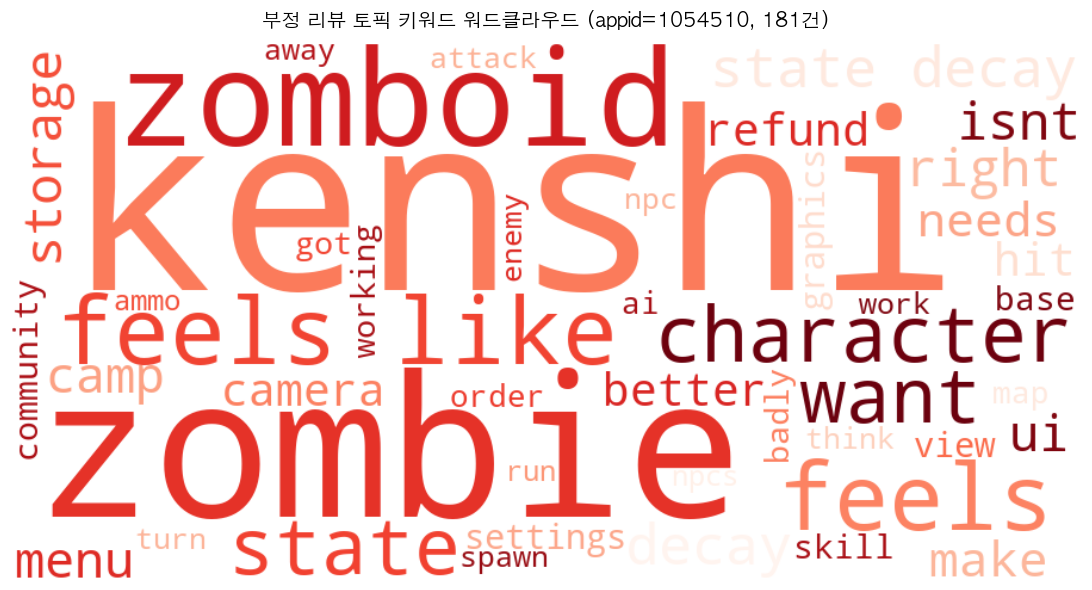

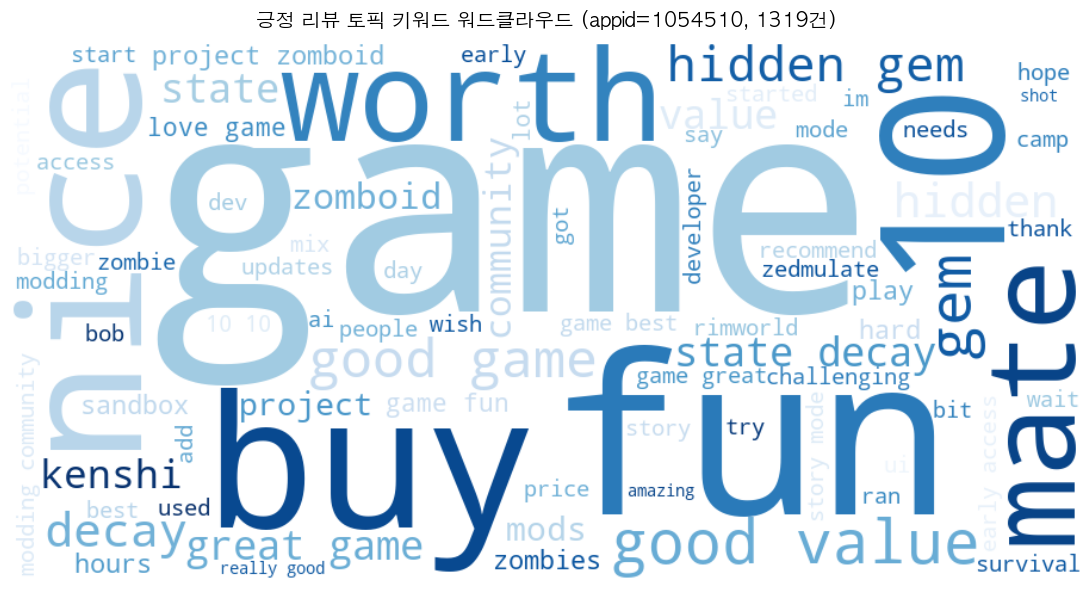

In [13]:

def make_wordcloud_from_topics(topic_model: BERTopic, title: str, colormap: str) -> None:
    info = topic_model.get_topic_info()
    info = info[info['Topic'] != -1]

    # c-TF-IDF 점수를 가중치로 사용 (건수 대신)
    word_freq = {}
    for _, row in info.iterrows():
        for word, score in topic_model.get_topic(row['Topic']):
            word_freq[word] = word_freq.get(word, 0) + score

    if not word_freq:
        print(f"{title}: 워드클라우드에 표시할 토픽 키워드가 없습니다.")
        return

    wc = WordCloud(
        width=900, height=450,
        background_color='white',
        colormap=colormap,
        max_words=80,
        collocations=False,
    ).generate_from_frequencies(word_freq)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()

make_wordcloud_from_topics(
    topic_model_neg,
    f'부정 리뷰 토픽 키워드 워드클라우드 (appid={TARGET_APPID}, {len(neg_docs)}건)',
    colormap='Reds',
)
make_wordcloud_from_topics(
    topic_model_pos,
    f'긍정 리뷰 토픽 키워드 워드클라우드 (appid={TARGET_APPID}, {len(pos_docs)}건)',
    colormap='Blues',
)


**해석:** 워드클라우드의 단어 크기는 c-TF-IDF 점수 기반 가중치로, 전체 리뷰 대비 해당 토픽에서 특히 두드러지는 단어일수록 크게 표시됩니다.
부정 워드클라우드에서 버그·성능 관련 단어가 두드러질수록 기술적 완성도가 주요 불만 요인임을 나타냅니다.
긍정 워드클라우드에서는 게임의 핵심 강점(아트, 스토리, 분위기 등)을 파악할 수 있습니다.

부정 문서 UMAP 2D 축소 중...
저장 완료: ../../../../data/processed/embeddings_2d_부정_1054510.npy


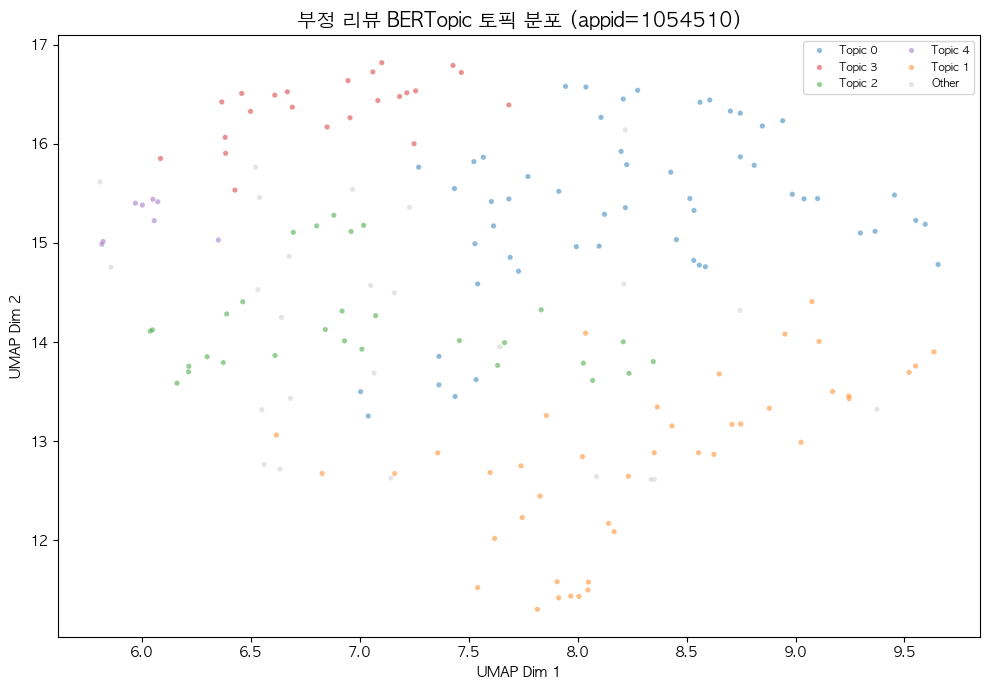

긍정 문서 UMAP 2D 축소 중...
저장 완료: ../../../../data/processed/embeddings_2d_긍정_1054510.npy


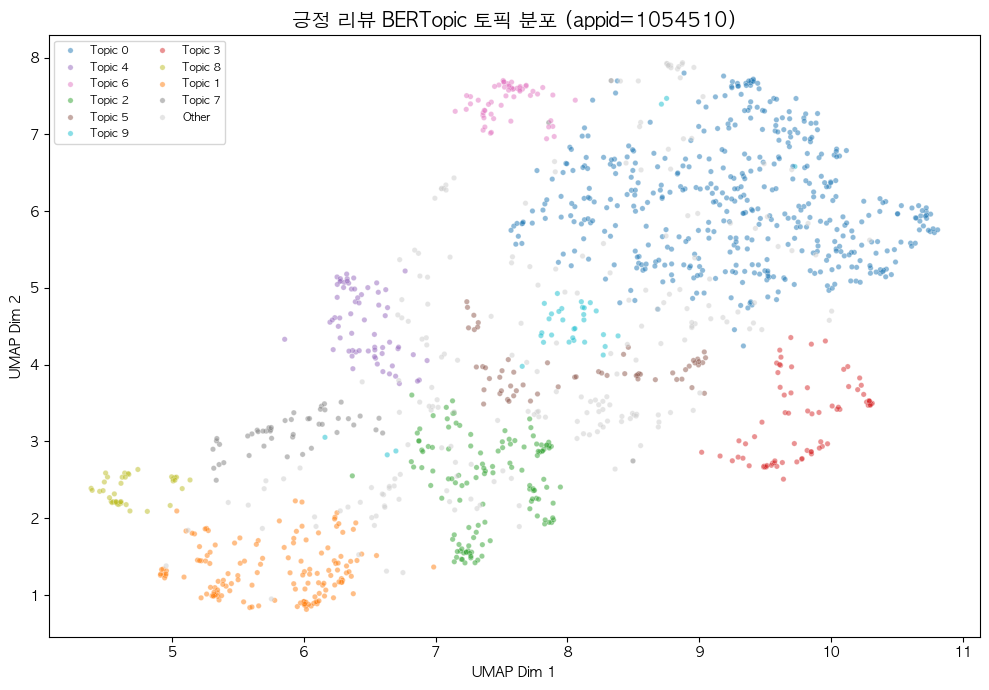

In [14]:

def plot_umap_2d(docs, embeddings, topic_model, topic_info, label, colormap, appid):
    path = f'../../../../data/processed/embeddings_2d_{label}_{appid}.npy'
    emb_2d = None
    if os.path.exists(path):
        cached = np.load(path)
        if cached.shape[0] == len(docs):
            emb_2d = cached
            print(f"2D 임베딩 로드 완료: {path}")
        else:
            print(f"2D 임베딩 캐시 무효: {cached.shape[0]} != {len(docs)} → 재생성")

    if emb_2d is None:
        umap_2d = UMAP(
            n_components=2,
            n_neighbors=min(15, max(2, len(docs) - 1)),
            min_dist=0.0,
            metric="cosine",
            random_state=42,
        )
        print(f"{label} 문서 UMAP 2D 축소 중...")
        emb_2d = umap_2d.fit_transform(embeddings)
        np.save(path, emb_2d)
        print(f"저장 완료: {path}")

    topics = topic_model.topics_
    top_topic_ids = [f"Topic {t}" for t in topic_info[topic_info["Topic"] != -1]["Topic"].values[:10]]

    df_viz = pd.DataFrame({
        "UMAP Dim 1": emb_2d[:, 0],
        "UMAP Dim 2": emb_2d[:, 1],
        "topic": [f"Topic {t}" if t != -1 else "Noise" for t in topics],
    })
    df_viz["topic_color"] = df_viz["topic"].apply(lambda x: x if x in top_topic_ids else "Other")

    palette = {t: c for t, c in zip(top_topic_ids, sns.color_palette("tab10", len(top_topic_ids)))}
    palette["Other"] = (0.8, 0.8, 0.8)

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(
        data=df_viz.sort_values("topic_color", key=lambda x: x == "Other"),
        x="UMAP Dim 1", y="UMAP Dim 2",
        hue="topic_color", palette=palette, alpha=0.5, s=15, ax=ax
    )
    ax.set_title(f"{label} 리뷰 BERTopic 토픽 분포 (appid={appid})", fontsize=14)
    ax.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

plot_umap_2d(neg_docs, neg_embeddings, topic_model_neg, neg_topic_info, '부정', 'Reds', TARGET_APPID)
plot_umap_2d(pos_docs, pos_embeddings, topic_model_pos, pos_topic_info, '긍정', 'Blues', TARGET_APPID)


## 집계 결과 저장 (LLM 입력용)

BERTopic 토픽 키워드와 건수를 구조화된 JSON으로 저장합니다.
카테고리 레이블링은 다음 단계(03 노트북)에서 LLM이 토픽 키워드를 보고 수행합니다.

In [15]:

import json


def build_topic_summary(topic_model: BERTopic, topic_info: pd.DataFrame, top_n_words: int = 5) -> list[dict]:
    result = []
    for _, row in topic_info[topic_info['Topic'] != -1].iterrows():
        topic_id = row['Topic']
        keywords = [word for word, _ in topic_model.get_topic(topic_id)[:top_n_words]]
        result.append({
            "topic_id": int(topic_id),
            "count": int(row['Count']),
            "keywords": keywords,
        })
    return result


summary = {
    "appid": TARGET_APPID,
    "total_reviews": len(df_game),
    "modeling": {
        "embedding_model": EMBEDDING_MODEL_NAME,
        "topic_model": "BERTopic",
    },
    "negative": {
        "count": len(df_neg),
        "min_cluster_size": int(neg_mcs),
        "diagnostics": neg_diagnostics,
        "topics": build_topic_summary(topic_model_neg, neg_topic_info),
    },
    "positive": {
        "count": len(df_pos),
        "min_cluster_size": int(pos_mcs),
        "diagnostics": pos_diagnostics,
        "topics": build_topic_summary(topic_model_pos, pos_topic_info),
    },
}

output_path = f'../../../../data/processed/review_analysis_summary_{TARGET_APPID}.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {output_path}")
print(json.dumps(summary, ensure_ascii=False, indent=2))


저장 완료: ../../../../data/processed/review_analysis_summary_1054510.json
{
  "appid": 1054510,
  "total_reviews": 1500,
  "modeling": {
    "embedding_model": "avsolatorio/GIST-small-Embedding-v0",
    "topic_model": "BERTopic"
  },
  "negative": {
    "count": 181,
    "min_cluster_size": 8,
    "diagnostics": {
      "topic_count": 5,
      "noise_count": 25,
      "noise_ratio": 0.138,
      "largest_topic_ratio": 0.298,
      "warnings": []
    },
    "topics": [
      {
        "topic_id": 0,
        "count": 54,
        "keywords": [
          "camp",
          "make",
          "base",
          "zombie",
          "map"
        ]
      },
      {
        "topic_id": 1,
        "count": 42,
        "keywords": [
          "menu",
          "ui",
          "want",
          "camera",
          "refund"
        ]
      },
      {
        "topic_id": 2,
        "count": 29,
        "keywords": [
          "character",
          "better",
          "view",
          "community",
     